In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests
from tqdm import tqdm
import random
import re
import math
import networkx as nx
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
def load_names():
    urls = [
        "https://www.cs.cmu.edu/afs/cs/project/ai-repository/ai/areas/nlp/corpora/names/male.txt",
        "https://www.cs.cmu.edu/afs/cs/project/ai-repository/ai/areas/nlp/corpora/names/female.txt"
    ]
    names = []
    for url in urls:
        response = requests.get(url)
        if response.status_code == 200:
            for line in response.text.split('\n'):
                if line and not line.startswith('#'):
                    names.append(line.strip().lower())
    print(f"Total number of names loaded: {len(names)}")
    return names

print("Loading names...")
names = load_names()

Loading names...
Total number of names loaded: 7944


In [3]:
def create_char_maps(names):
    chars = set(''.join(names))
    chars = sorted(chars)

    char_to_ix = {char: i + 1 for i, char in enumerate(chars)}
    char_to_ix['<PAD>'] = 0
    char_to_ix['<END>'] = len(char_to_ix)
    char_to_ix['<MASK>'] = len(char_to_ix)

    ix_to_char = {v: k for k, v in char_to_ix.items()}

    print(f"Total number of unique characters: {len(chars)}")
    print(f"Characters: {''.join(chars)}")
    return char_to_ix, ix_to_char

print("\nCreating character mappings...")
char_to_ix, ix_to_char = create_char_maps(names)


Creating character mappings...
Total number of unique characters: 29
Characters:  '-abcdefghijklmnopqrstuvwxyz


In [4]:
def pad_sequence(sequence, max_len, padding_value):
    if len(sequence) >= max_len:
        return sequence[:max_len]
    return sequence + [padding_value] * (max_len - len(sequence))

# 双向数据集实现
class BiDirectionalNameDataset(Dataset):
    def __init__(self, names, char_to_ix, direction='forward', mask_prob=0.3):
        self.names = names
        self.char_to_ix = char_to_ix
        self.direction = direction
        self.max_len = max(len(name) for name in names) + 1  # +1 用于添加 <END> 标记
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        # 如果是反向模型,需要将名字反转
        if self.direction == 'backward':
            name = name[::-1]

        # 将字符转换为索引
        input_seq = [self.char_to_ix[c] for c in name]
        target_seq = input_seq + [self.char_to_ix['<END>']]
        input_seq = [self.char_to_ix['<PAD>']] + input_seq

        # 随机遮盖部分字符用于训练
        input_seq_masked = []
        for ix in input_seq:
            if ix != self.char_to_ix['<PAD>'] and random.random() < self.mask_prob:
                input_seq_masked.append(self.char_to_ix['<MASK>'])
            else:
                input_seq_masked.append(ix)

        # 对序列进行填充
        input_seq = pad_sequence(input_seq_masked, self.max_len + 1, self.char_to_ix['<PAD>'])
        target_seq = pad_sequence(target_seq, self.max_len + 1, self.char_to_ix['<PAD>'])

        return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

# 创建正向和反向数据集
forward_dataset = BiDirectionalNameDataset(names, char_to_ix, direction='forward')
backward_dataset = BiDirectionalNameDataset(names, char_to_ix, direction='backward')

forward_dataloader = DataLoader(dataset=forward_dataset, batch_size=64, shuffle=True)
backward_dataloader = DataLoader(dataset=backward_dataset, batch_size=64, shuffle=True)

In [17]:
class PhonemeRules:
    def __init__(self, char_to_ix):
        self.char_to_ix = char_to_ix
        self.vowels = set('aeiou')
        self.consonants = set('bcdfghjklmnpqrstvwxyz')
    def get_mask(self, last_char_idx):
        mask = torch.ones(len(self.char_to_ix), dtype=torch.float32)
        last_char = ix_to_char.get(last_char_idx.item(), '')

        if last_char in self.vowels:
            for v in self.vowels:
                idx = self.char_to_ix.get(v, None)
                if idx is not None:
                    mask[idx] *= 0.5  # 降低连续元音的概率
            for c in self.consonants:
                idx = self.char_to_ix.get(c, None)
                if idx is not None:
                    mask[idx] *= 1.5  # 提高元音后跟辅音的概率
        elif last_char in self.consonants:
            for c in self.consonants:
                idx = self.char_to_ix.get(c, None)
                if idx is not None:
                    mask[idx] *= 0.5  # 降低连续辅音的概率
            for v in self.vowels:
                idx = self.char_to_ix.get(v, None)
                if idx is not None:
                    mask[idx] *= 1.5  # 提高辅音后跟元音的概率
        mask = torch.clamp(mask, 0.1, 2.0)
        return mask

In [5]:
class MaskedNameGenerator(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.hidden_size = hidden_size
        self.num_layers = num_layers
    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        if hidden is None:
            output, hidden = self.lstm(embedded)
        else:
            output, hidden = self.lstm(embedded, hidden)
        output = self.fc(output)
        return output, hidden

# 双向模型实现
class BiDirectionalNameGenerator:
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0.1):
        # 创建正向和反向两个LSTM模型
        self.forward_model = MaskedNameGenerator(input_size, hidden_size, output_size,
                                               num_layers, dropout).to(device)
        self.backward_model = MaskedNameGenerator(input_size, hidden_size, output_size,
                                                num_layers, dropout).to(device)
        self.phoneme_rules = PhonemeRules(char_to_ix)

        # 为两个模型创建独立的优化器
        self.forward_optimizer = optim.Adam(self.forward_model.parameters(), lr=0.005)
        self.backward_optimizer = optim.Adam(self.backward_model.parameters(), lr=0.005)

        self.criterion = nn.CrossEntropyLoss(ignore_index=char_to_ix['<PAD>'])

    def train_epoch(self, forward_dataloader, backward_dataloader, epoch):
        # 训练正向模型
        self.forward_model.train()
        forward_loss = self._train_model(self.forward_model, self.forward_optimizer,
                                       forward_dataloader, "正向", epoch)

        # 训练反向模型
        self.backward_model.train()
        backward_loss = self._train_model(self.backward_model, self.backward_optimizer,
                                        backward_dataloader, "反向", epoch)

        return forward_loss, backward_loss

    def _train_model(self, model, optimizer, dataloader, direction, epoch):
        total_loss = 0
        desc = f"轮次 {epoch} ({direction})"

        for batch_x, batch_y in tqdm(dataloader, desc=desc):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            outputs, _ = model(batch_x)
            outputs = outputs.view(-1, outputs.size(-1))
            batch_y = batch_y.view(-1)

            loss = self.criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        return total_loss / len(dataloader)

    def _get_top_k_probs(self, probs, k=5):
        """获取概率最高的k个字符及其概率"""
        top_k_probs, top_k_indices = torch.topk(probs, k)
        return [(ix_to_char[idx.item()], prob.item()) for prob, idx in zip(top_k_probs, top_k_indices)]

    def generate_name_with_prefix(self, prefix, max_len=20):
        """根据前缀生成名字，并记录生成过程"""
        model = self.forward_model
        model.eval()
        generation_steps = []  # 记录每一步的生成过程

        with torch.no_grad():
            constraint_chars = [char_to_ix[c.lower()] for c in prefix]
            input_seq = [char_to_ix['<PAD>']] + constraint_chars
            input_seq = torch.tensor([input_seq], dtype=torch.long).to(device)

            hidden = None
            generated = prefix

            for _ in range(max_len - len(prefix)):
                outputs, hidden = model(input_seq, hidden)
                last_output = outputs[:, -1, :]
                probs = torch.softmax(last_output.squeeze(0), dim=-1)

                # 应用音素规则
                last_char_idx = input_seq[0, -1]
                mask = self.phoneme_rules.get_mask(last_char_idx).to(device)
                probs = probs * mask
                probs = probs / probs.sum()

                # 记录当前步骤的top5概率
                top_chars = self._get_top_k_probs(probs)
                generation_steps.append({
                    'position': len(generated),
                    'current_name': generated,
                    'top_probabilities': top_chars
                })

                # 采样下一个字符
                next_char_idx = torch.multinomial(probs, 1).item()
                next_char = ix_to_char[next_char_idx]

                if next_char == '<END>':
                    break

                generated += next_char
                input_seq = torch.cat([
                    input_seq,
                    torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
                ], dim=1)

            return generated.capitalize(), generation_steps

    def generate_name_with_suffix(self, suffix, max_len=20):
        """根据后缀生成名字，并记录生成过程"""
        suffix = suffix.lower()
        generation_steps = []

        with torch.no_grad():
            constraint_chars = [char_to_ix[c] for c in suffix[::-1]]
            input_seq = [char_to_ix['<PAD>']] + constraint_chars
            input_seq = torch.tensor([input_seq], dtype=torch.long).to(device)

            hidden = None
            generated = suffix[::-1]  # 反转后缀

            for _ in range(max_len - len(suffix)):
                outputs, hidden = self.backward_model(input_seq, hidden)
                last_output = outputs[:, -1, :]
                probs = torch.softmax(last_output.squeeze(0), dim=-1)

                last_char_idx = input_seq[0, -1]
                mask = self.phoneme_rules.get_mask(last_char_idx).to(device)
                probs = probs * mask
                probs = probs / probs.sum()

                # 记录当前步骤的top5概率
                top_chars = self._get_top_k_probs(probs)
                generation_steps.append({
                    'position': len(generated),
                    'current_name': generated[::-1],  # 记录当前名字（反转回正常方向）
                    'top_probabilities': top_chars
                })

                next_char_idx = torch.multinomial(probs, 1).item()
                next_char = ix_to_char[next_char_idx]

                if next_char == '<END>':
                    break

                generated = next_char + generated  # 在左边添加字符
                input_seq = torch.cat([
                    input_seq,
                    torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
                ], dim=1)

            final_name = generated[::-1].capitalize()  # 最终反转并大写首字母
            return final_name, generation_steps

    def generate_name_with_middle(self, middle, max_len=20):
        """从中间向两边生成名字，并记录生成过程"""
        middle = middle.lower()
        left_seq = middle
        right_seq = middle
        generation_steps = []

        left_ended = False
        right_ended = False
        left_hidden = None
        right_hidden = None

        while (not left_ended or not right_ended) and len(left_seq) + len(right_seq) - len(middle) < max_len:
            current_name = left_seq + right_seq[len(middle):]

            # 向左生成
            if not left_ended:
                left_input = [char_to_ix[c] for c in left_seq[::-1]]
                left_input = [char_to_ix['<PAD>']] + left_input
                left_input = torch.tensor([left_input], dtype=torch.long).to(device)

                with torch.no_grad():
                    outputs, left_hidden = self.backward_model(left_input, left_hidden)
                    last_output = outputs[:, -1, :]
                    probs = torch.softmax(last_output.squeeze(0), dim=-1)

                    last_char_idx = left_input[0, -1]
                    mask = self.phoneme_rules.get_mask(last_char_idx).to(device)
                    probs = probs * mask
                    probs = probs / probs.sum()

                    # 记录左向生成的概率
                    top_chars = self._get_top_k_probs(probs)
                    generation_steps.append({
                        'position': 'left',
                        'current_name': current_name,
                        'top_probabilities': top_chars
                    })

                    next_char_idx = torch.multinomial(probs, 1).item()
                    next_char = ix_to_char[next_char_idx]

                    if next_char == '<END>':
                        left_ended = True
                    else:
                        left_seq = next_char + left_seq

            # 向右生成
            if not right_ended:
                right_input = [char_to_ix[c] for c in right_seq]
                right_input = [char_to_ix['<PAD>']] + right_input
                right_input = torch.tensor([right_input], dtype=torch.long).to(device)

                with torch.no_grad():
                    outputs, right_hidden = self.forward_model(right_input, right_hidden)
                    last_output = outputs[:, -1, :]
                    probs = torch.softmax(last_output.squeeze(0), dim=-1)

                    last_char_idx = right_input[0, -1]
                    mask = self.phoneme_rules.get_mask(last_char_idx).to(device)
                    probs = probs * mask
                    probs = probs / probs.sum()

                    # 记录右向生成的概率
                    top_chars = self._get_top_k_probs(probs)
                    generation_steps.append({
                        'position': 'right',
                        'current_name': current_name,
                        'top_probabilities': top_chars
                    })

                    next_char_idx = torch.multinomial(probs, 1).item()
                    next_char = ix_to_char[next_char_idx]

                    if next_char == '<END>':
                        right_ended = True
                    else:
                        right_seq = right_seq + next_char

            if left_ended and right_ended:
                break

        return current_name.capitalize(), generation_steps

    def _generate_with_constraint(self, model, constraint, is_prefix=True, max_len=20):
        model.eval()
        with torch.no_grad():
            # 准备输入序列
            constraint_chars = [char_to_ix[c.lower()] for c in constraint]
            input_seq = [char_to_ix['<PAD>']] + constraint_chars
            input_seq = torch.tensor([input_seq], dtype=torch.long).to(device)

            hidden = None
            generated = constraint

            # 生成剩余字符
            for _ in range(max_len - len(constraint)):
                outputs, hidden = model(input_seq, hidden)
                last_output = outputs[:, -1, :]
                probs = torch.softmax(last_output.squeeze(0), dim=-1)

                # 应用音素规则
                last_char_idx = input_seq[0, -1]
                mask = self.phoneme_rules.get_mask(last_char_idx).to(device)
                probs = probs * mask
                probs = probs / probs.sum()

                # 采样下一个字符
                next_char_idx = torch.multinomial(probs, 1).item()
                next_char = ix_to_char[next_char_idx]

                if next_char == '<END>':
                    break

                generated += next_char
                input_seq = torch.cat([
                    input_seq,
                    torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
                ], dim=1)

            return generated.capitalize()


# 初始化双向生成器
generator = BiDirectionalNameGenerator(
    input_size=len(char_to_ix),
    hidden_size=128,
    output_size=len(char_to_ix),
    num_layers=2
)

In [6]:
# 训练循环
num_epochs = 200
for epoch in range(1, num_epochs + 1):
    forward_loss, backward_loss = generator.train_epoch(forward_dataloader, backward_dataloader, epoch)
    print(f"轮次 {epoch}")
    print(f"正向损失: {forward_loss:.4f}")
    print(f"反向损失: {backward_loss:.4f}")
    print("-" * 50)

轮次 1 (反向): 100%|██████████| 125/125 [00:00<00:00, 239.64it/s]


轮次 1
正向损失: 2.4862
反向损失: 2.4993
--------------------------------------------------


轮次 2 (反向): 100%|██████████| 125/125 [00:00<00:00, 223.92it/s]


轮次 2
正向损失: 2.3175
反向损失: 2.3273
--------------------------------------------------


轮次 3 (反向): 100%|██████████| 125/125 [00:00<00:00, 247.89it/s]


...

轮次 198
正向损失: 1.9188
反向损失: 1.9475
--------------------------------------------------


轮次 199 (反向): 100%|██████████| 125/125 [00:00<00:00, 261.70it/s]


轮次 199
正向损失: 1.9101
反向损失: 1.9461
--------------------------------------------------


轮次 200 (反向): 100%|██████████| 125/125 [00:00<00:00, 262.10it/s]

轮次 200
正向损失: 1.9133
反向损失: 1.9438
--------------------------------------------------


In [13]:
prefix_test = "Al"
suffix_test = "son"
middle_test = "ann"

# 使用前缀生成
generated_with_prefix, steps_with_prefix = generator.generate_name_with_prefix(prefix_test)

# 使用后缀生成
generated_with_suffix, steps_with_suffix = generator.generate_name_with_suffix(suffix_test)

# 从中间生成
generated_with_middle, steps_with_middle = generator.generate_name_with_middle(middle_test)


print(f"\n使用前缀 '{prefix_test}' 生成的名字: {generated_with_prefix}")
print(f"使用后缀 '{suffix_test}' 生成的名字: {generated_with_suffix}")
print(f"使用中间部分 '{middle_test}' 生成的名字: {generated_with_middle}")


使用前缀 'Al' 生成的名字: Alia
使用后缀 'son' 生成的名字: Sonrac
使用中间部分 'ann' 生成的名字: Jeanna


In [9]:
def visualize_generation_step(ax, step, step_idx):
    """
    为单个生成步骤创建柱状图，展示概率最高的前5个字符

    参数:
        ax: matplotlib 坐标轴对象
        step: 包含生成步骤信息的字典
        step_idx: 当前步骤的索引
    """
    # 提取可视化所需的数据
    chars, probs = zip(*step['top_probabilities'])
    probs = [p * 100 for p in probs]  # 将概率转换为百分比

    # 创建柱状图
    bars = ax.bar(range(len(chars)), probs, color='royalblue', alpha=0.7)

    # 自定义图表样式
    ax.set_xticks(range(len(chars)))
    ax.set_xticklabels(chars)
    ax.set_ylim(0, 100)

    # 在柱子顶部添加数值标签
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom')

    # 添加标题和标签
    if step['position'] == 'left':
        position_text = 'Left Generation'
    elif step['position'] == 'right':
        position_text = 'Right Generation'
    else:
        position_text = f'Position {step["position"]}'

    ax.set_title(f'Step {step_idx + 1}: {position_text}\nCurrent Name: {step["current_name"]}')
    ax.set_ylabel('Probability (%)')
    ax.set_xlabel('Characters')

    # 添加网格线提高可读性
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

def visualize_generation_process(generation_steps, title):
    """
    创建包含所有生成步骤的子图

    参数:
        generation_steps: 包含生成步骤信息的字典列表
        title: 整个图表的标题
    """
    num_steps = len(generation_steps)
    # 计算子图的行数和列数
    num_cols = min(3, num_steps)
    num_rows = (num_steps + num_cols - 1) // num_cols

    # 创建图表和子图
    fig_width = 6 * num_cols
    fig_height = 4 * num_rows
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height))
    fig.suptitle(title, fontsize=16, y=1.02)

    # 如果有多行，将坐标轴数组展平
    if num_rows > 1:
        axes = axes.flatten()
    elif num_rows == 1 and num_cols == 1:
        axes = [axes]

    # 为每个步骤创建可视化
    for i, step in enumerate(generation_steps):
        visualize_generation_step(axes[i], step, i)

    # 移除多余的空子图
    for i in range(num_steps, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    return fig

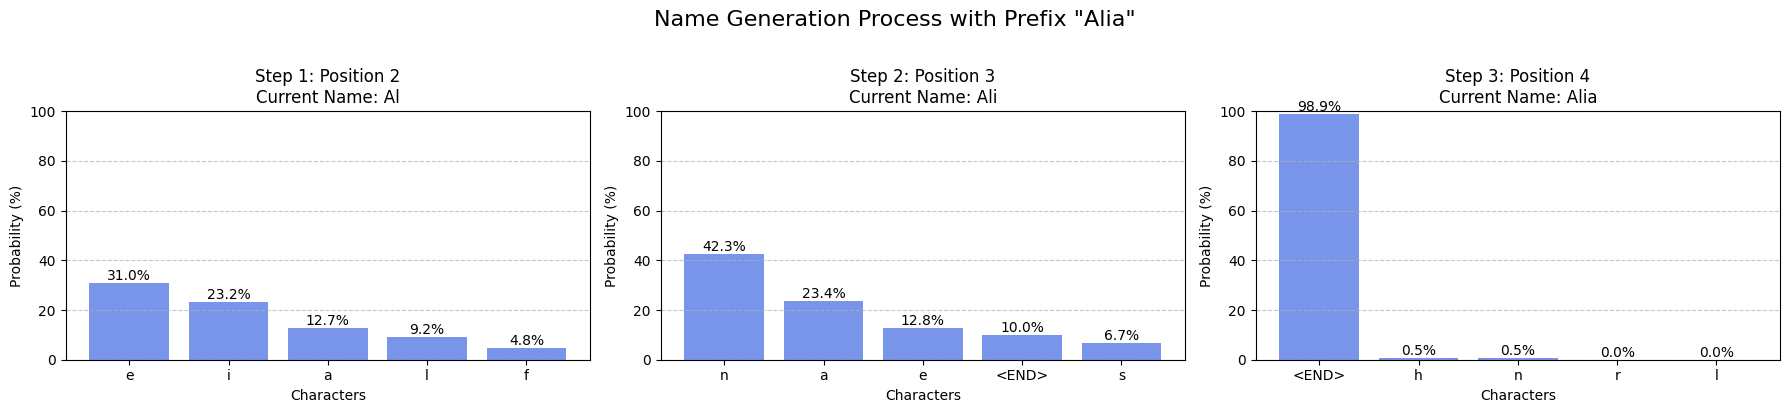

In [14]:
fig = visualize_generation_process(steps_with_prefix, f'Name Generation Process with Prefix "{generated_with_prefix}"')
plt.show()

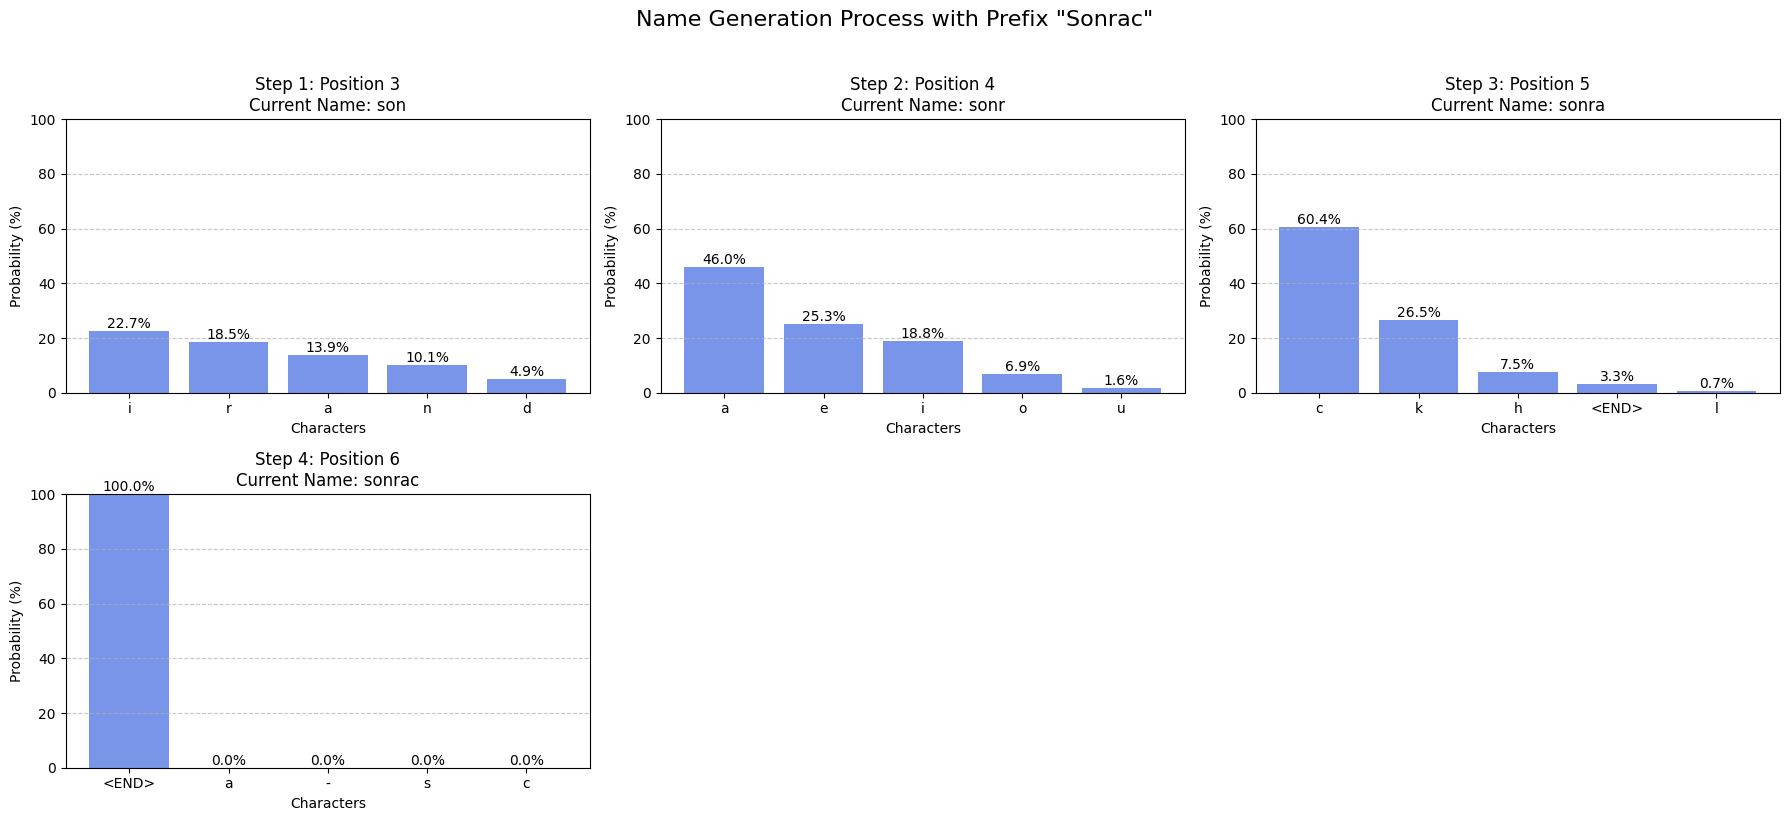

In [15]:
fig = visualize_generation_process(steps_with_suffix, f'Name Generation Process with Prefix "{generated_with_suffix}"')
plt.show()

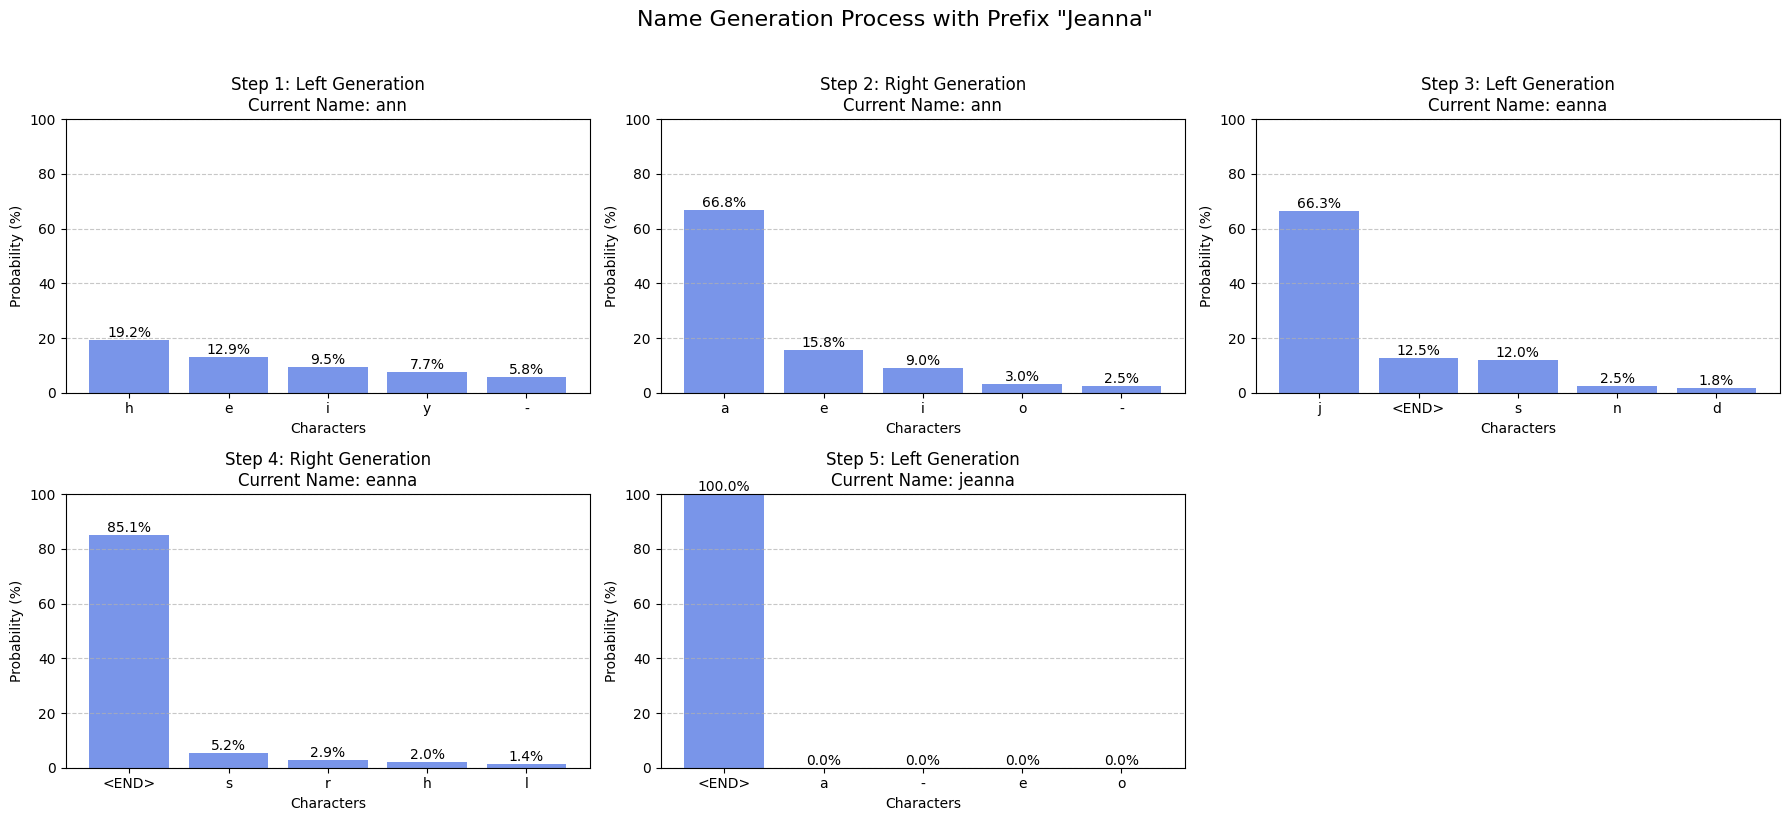

In [16]:
fig = visualize_generation_process(steps_with_middle, f'Name Generation Process with Prefix "{generated_with_middle}"')
plt.show()